<a href="https://colab.research.google.com/github/Car27VeP/Data_Science_Projects/blob/main/From_Medical_Transactions_to_Patient_Profile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your goal is to practice **Data Preparation** by transforming a messy list of laboratory records into a clean, structured table ready for a predictive model.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Simulate 1,000 medical records (transactions)
np.random.seed(42)
n_records = 1000
patients = [101, 102, 103, 104, 105]

data = {
    'record_id': range(1, n_records + 1),
    'patient_id': np.random.choice(patients, n_records),
    'lab_result': np.random.uniform(50, 150, n_records), # Lab analysis result
    'visit_date': pd.to_datetime(np.random.choice(pd.date_range('2026-01-01', '2026-04-30'), n_records))
}

df_transactions = pd.DataFrame(data)

In [3]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   record_id   1000 non-null   int64         
 1   patient_id  1000 non-null   int64         
 2   lab_result  1000 non-null   float64       
 3   visit_date  1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 31.4 KB


In [4]:
df_transactions.head()

,record_id,patient_id,lab_result,visit_date
0,1,104,143.211828,2026-02-12
1,2,105,106.513318,2026-01-01
2,3,103,119.665082,2026-04-19
3,4,105,142.249938,2026-02-20
4,5,105,120.723863,2026-01-24


In [5]:
df_transactions.describe()

,record_id,patient_id,lab_result,visit_date
count,1000.000000,1000.000000,1000.000000,1000
mean,500.500000,103.004000,100.024429,2026-02-28 19:29:16.800000
min,1.000000,101.000000,50.463202,2026-01-01 00:00:00
25%,250.750000,102.000000,73.569837,2026-01-28 00:00:00
50%,500.500000,103.000000,100.435397,2026-02-27 00:00:00
75%,750.250000,104.000000,124.504415,2026-04-01 00:00:00
max,1000.000000,105.000000,149.941373,2026-04-30 00:00:00
std,288.819436,1.433192,29.271852,NaN


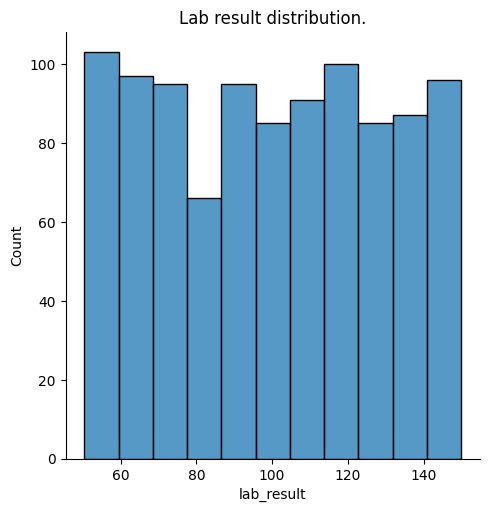

In [7]:
# Lab result Distribution.
sns.displot(df_transactions['lab_result'])
plt.title("Lab result distribution.")
plt.show()

# Technical Task (The "Data Prep" Stage)
Transform df_transactions into a new DataFrame called df_patients. It must follow these requirements:

- One row per patient_id (Aggregate the data).

- New Columns:

    1. avg_result: The average of all their lab results.

    2. total_visits: The count of how many times that patient appears in the table.

    3. is_at_risk: A boolean column (True/False) that is True if their avg_result is greater than 100.

In [19]:
df_patients = df_transactions.groupby('patient_id').agg(
    avg_result = ('lab_result','mean'),
    total_visits = ('visit_date','count')
)

df_patients['is_at_risk'] = np.where(df_patients['avg_result'] >= 100,True,False)

In [20]:
df_patients.head()

,avg_result,total_visits,is_at_risk
patient_id,,,
101,98.331517,210,False
102,101.763709,190,True
103,98.706715,190,False
104,102.137850,206,True
105,99.240357,204,False


Why did we aggregate the data from 1,000 rows to only 5?

To shrink the dataset, as the transaction dataset includes clinical information of only 5 patients. It'll be easier to visualize it by making a little statistical description.

If a doctor asks you, "Which patient should I prioritize?", look at your is_at_risk column and provide a professional answer.

We are going to answer that patients 102 and 104 are the priority as their results are above from the mean.

# **BONUS: SQL QUERY**

In [21]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=f357108fe0be968b67498357a21538564eaa39528105867eaeba3e94f889ebe8
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [29]:
from pandasql import sqldf

query = """
SELECT
  patient_id,
  AVG(lab_result) AS avg_results,
  COUNT(visit_date) AS total_visits,
  CASE
    WHEN AVG(lab_result) > 100 THEN 'True'
    ELSE 'False'
    END AS at_risk
FROM
  df_transactions
GROUP BY
  patient_id

"""

In [30]:
df_patients_sql = sqldf(query, locals())
print(df_patients_sql)

   patient_id  avg_results  total_visits at_risk
0         101    98.331517           210   False
1         102   101.763709           190    True
2         103    98.706715           190   False
3         104   102.137850           206    True
4         105    99.240357           204   False
